# What an LLM actually sees: tokens and embeddings

**The Agent Build Log · Build #001 · GenAI & LLM Foundations 1/8**

An LLM never reads your words. It reads **token IDs**, then turns each one into a **vector**.
This notebook shows both steps with real measurements:

1. [Text → tokens → IDs](#1-text--tokens--ids): what a tokenizer does to one sentence
2. [Where tokenizers get weird](#2-where-tokenizers-get-weird): numbers, spaces, code, emoji, typos
3. [Every model counts differently](#3-every-model-counts-differently): 4 real tokenizers, same text
4. [Same meaning, different price](#4-same-meaning-different-price): English vs Spanish
5. [Embeddings: meaning, not words](#5-embeddings-meaning-not-words)
6. [Context changes the vector](#6-context-changes-the-vector-bank-vs-bank)
7. [A map of meaning](#7-a-map-of-meaning)
8. [Findings](#8-findings)

**Cost to run: $0. No API key needed.** Every tokenizer and the embedding model are open and run locally
(first run downloads ~0.5 GB of model files).

In [1]:
import json, os
from pathlib import Path

import numpy as np
import pandas as pd
import tiktoken
from transformers import AutoTokenizer

pd.set_option("display.width", 140)
DATA = json.loads(Path("data/sentences.json").read_text())

# Sections 1-2 use GPT-4o's open tokenizer (o200k_base) to show token boundaries.
enc = tiktoken.get_encoding("o200k_base")

## 1. Text → tokens → IDs

A tokenizer splits text into pieces from a fixed vocabulary and maps each piece to an integer ID.
The model only ever receives the IDs.

In [2]:
ex_text = DATA["worked_example"]
ex_ids = enc.encode(ex_text)
ex_pieces = [enc.decode([i]) for i in ex_ids]

print("TEXT   :", ex_text)
print("TOKENS :", " | ".join(repr(p)[1:-1] for p in ex_pieces))
print("IDS    :", ex_ids)
print(f"\n{len(ex_text)} characters -> {len(ex_ids)} tokens")

TEXT   : Tokenization isn't free: 'unbelievably' costs more than 'good'.
TOKENS : Token | ization |  isn't |  free | : |  ' | un | bel | ievably | ' |  costs |  more |  than |  ' | good | '.
IDS    : [4421, 2860, 12471, 2240, 25, 461, 373, 9880, 153516, 6, 8959, 945, 1572, 461, 30744, 6120]

63 characters -> 16 tokens


## 2. Where tokenizers get weird

Tokenizers were trained on frequency, not meaning. Common strings become one token;
rare ones get chopped up. Watch the spaces: `" Hello"` and `"Hello"` are different tokens.

In [3]:
rows = []
for group, items in DATA["edge_cases"].items():
    for s in items:
        tids = enc.encode(s)
        rows.append({"group": group, "text": repr(s), "tokens": len(tids),
                     "pieces": " | ".join(repr(enc.decode([i]))[1:-1] for i in tids),
                     "ids": tids})
edge = pd.DataFrame(rows)
edge

,group,text,tokens,pieces,ids
0,numbers,'2026',2,202 | 6,"[1323, 21]"
1,numbers,'12345.678',4,123 | 45 | . | 678,"[7633, 2548, 13, 30833]"
2,numbers,'3.14159',4,3 | . | 141 | 59,"[18, 13, 16926, 4621]"
3,numbers,"'1,000,000'",5,"1 | , | 000 | , | 000","[16, 11, 1302, 11, 1302]"
4,numbers,'0x1F4A',6,0 | x | 1 | F | 4 | A,"[15, 87, 16, 37, 19, 32]"
5,spacing,'Hello',1,Hello,[13225]
6,spacing,' Hello',1,Hello,[32949]
7,spacing,'hello',1,hello,[24912]
8,spacing,'HELLO',2,HEL | LO,"[111642, 2699]"
9,spacing,' Hello',2,| Hello,"[220, 32949]"


## 3. Every model counts differently

There is no universal "token". Each model family trains its own vocabulary, so the **same text
costs a different number of tokens** depending on the model. Token counts drive price, latency and
how much fits in the context window, so an estimate from the wrong tokenizer is wrong.

We count the same 8 English sentences with four real tokenizers:

| Tokenizer | Used by | Vocabulary |
|---|---|---|
| `cl100k_base` | GPT-4, GPT-3.5 | ~100k |
| `o200k_base` | GPT-4o | ~200k |
| Qwen2.5 | Qwen2.5 open models | ~150k |
| XLM-R | multilingual encoders, incl. our embedding model | ~250k |

In [4]:
def tiktoken_counter(name):
    e = tiktoken.get_encoding(name)
    return lambda t: len(e.encode(t))

def hf_counter(repo):
    tok = AutoTokenizer.from_pretrained(repo)
    return lambda t: len(tok.encode(t, add_special_tokens=False))

TOKENIZERS = {
    "GPT-4 (cl100k)": tiktoken_counter("cl100k_base"),
    "GPT-4o (o200k)": tiktoken_counter("o200k_base"),
    "Qwen2.5": hf_counter("Qwen/Qwen2.5-0.5B"),
    "XLM-R (multilingual)": hf_counter("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"),
}
cols = list(TOKENIZERS)

counts = pd.DataFrame([{"lang": lang, "text": p[lang], **{n: f(p[lang]) for n, f in TOKENIZERS.items()}}
                       for p in DATA["parallel"] for lang in ("en", "es")])
totals = counts.groupby("lang")[cols].sum()
totals

,GPT-4 (cl100k),GPT-4o (o200k),Qwen2.5,XLM-R (multilingual)
lang,,,,
en,92,92,92,111
es,151,128,151,138


In [5]:
en = totals.loc["en"]
spread = pd.DataFrame({"tokenizer": cols, "EN tokens": [int(en[c]) for c in cols]})
spread["vs fewest"] = (spread["EN tokens"] / spread["EN tokens"].min()).round(2)
print(f"Same English text: {int(en.min())} to {int(en.max())} tokens "
      f"({(en.max() - en.min()) / en.min():.0%} spread across tokenizers)")
spread

Same English text: 92 to 111 tokens (21% spread across tokenizers)


,tokenizer,EN tokens,vs fewest
0,GPT-4 (cl100k),92,1.00
1,GPT-4o (o200k),92,1.00
2,Qwen2.5,92,1.00
3,XLM-R (multilingual),111,1.21


## 4. Same meaning, different price

The same 8 sentences in Spanish. Spanish text here is only slightly longer in characters, so how many
more tokens does it need, and does that depend on the tokenizer?

In [6]:
lang_cmp = pd.DataFrame({
    "tokenizer": cols,
    "EN tokens": [int(totals.loc["en", c]) for c in cols],
    "ES tokens": [int(totals.loc["es", c]) for c in cols],
})
lang_cmp["ES / EN"] = (lang_cmp["ES tokens"] / lang_cmp["EN tokens"]).round(2)
chars_ratio = round(counts[counts.lang == "es"].text.str.len().sum()
                    / counts[counts.lang == "en"].text.str.len().sum(), 2)
print(f"Characters, ES / EN: {chars_ratio}")
lang_cmp

Characters, ES / EN: 1.15


,tokenizer,EN tokens,ES tokens,ES / EN
0,GPT-4 (cl100k),92,151,1.64
1,GPT-4o (o200k),92,128,1.39
2,Qwen2.5,92,151,1.64
3,XLM-R (multilingual),111,138,1.24


## 5. Embeddings: meaning, not words

An embedding model turns a whole sentence into one vector. Sentences that mean the same thing
should end up close together (high cosine similarity), even when they share no words.
**Should.** The table below tests it, including sentences built to fool it.

We use `paraphrase-multilingual-MiniLM-L12-v2`, a small open model that runs on a laptop and
understands both English and Spanish. For each anchor sentence we compare four candidates:
a paraphrase with no shared words, a sentence with the **same words but a different meaning**,
a Spanish translation, and something unrelated.

In [7]:
from sentence_transformers import SentenceTransformer

emb_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

def embed(texts):
    return emb_model.encode(texts, normalize_embeddings=True)  # unit vectors: dot product = cosine

def word_overlap(a: str, b: str) -> float:
    wa = {w.strip("?.,¿!").lower() for w in a.split()}
    wb = {w.strip("?.,¿!").lower() for w in b.split()}
    return len(wa & wb) / len(wa | wb)

v = embed(["How do I reset my password?"])[0]
print(f"one sentence -> a vector of {len(v)} numbers, e.g. {np.round(v[:5], 3).tolist()} ...")

one sentence -> a vector of 384 numbers, e.g. [-0.05299999937415123, 0.010999999940395355, 0.010999999940395355, -0.06400000303983688, -0.09399999678134918] ...


In [8]:
rows = []
for s in DATA["embedding_sets"]:
    labels, texts = zip(*s["candidates"].items())
    vecs = embed([s["anchor"], *texts])
    for label, text, vec in zip(labels, texts, vecs[1:]):
        rows.append({"anchor": s["anchor"], "candidate": label, "text": text,
                     "cosine": float(vecs[0] @ vec), "word overlap": word_overlap(s["anchor"], text)})
sim = pd.DataFrame(rows)
sim.round(2)

,anchor,candidate,text,cosine,word overlap
0,How do I reset my password?,paraphrase (no shared words),"I forgot my login credentials, what should I do?",0.68,0.27
1,How do I reset my password?,"same words, different meaning",How do I reset my router?,0.44,0.71
2,How do I reset my password?,spanish translation,¿Cómo restablezco mi contraseña?,0.93,0.00
3,How do I reset my password?,unrelated,The weather in Madrid is sunny today.,-0.03,0.00
4,The customer wants their money back.,paraphrase (no shared words),A client is requesting a refund.,0.78,0.00
5,The customer wants their money back.,"same words, different meaning",The customer wants their order back on the shelf.,0.68,0.56
6,The customer wants their money back.,spanish translation,El cliente quiere que le devuelvan su dinero.,0.95,0.00
7,The customer wants their money back.,unrelated,Our office moves to a new building next week.,0.12,0.00
8,The deployment failed because of a timeout.,paraphrase (no shared words),Shipping the release broke: an operation ran t...,0.51,0.07
9,The deployment failed because of a timeout.,"same words, different meaning",The deployment of troops failed because of a t...,0.90,0.70


In [9]:
by_kind = (sim.groupby("candidate")[["cosine", "word overlap"]].mean()
              .sort_values("cosine", ascending=False).round(2))
by_kind

,cosine,word overlap
candidate,,
spanish translation,0.87,0.00
"same words, different meaning",0.67,0.66
paraphrase (no shared words),0.66,0.11
unrelated,0.04,0.00


## 6. Context changes the vector: bank vs bank

The word "bank" is one token, but the **sentence** vectors land in different places depending on
what the sentence is about.

In [10]:
bank_vecs = embed(DATA["bank"])
short = ["river bank", "stream bank", "deposit at bank", "bank loan"]
bank_sim = pd.DataFrame(bank_vecs @ bank_vecs.T, index=short, columns=short).round(2)
bank_sim

,river bank,stream bank,deposit at bank,bank loan
river bank,1.00,0.36,0.25,0.18
stream bank,0.36,1.00,0.06,-0.02
deposit at bank,0.25,0.06,1.00,0.46
bank loan,0.18,-0.02,0.46,1.00


## 7. A map of meaning

All sentences, projected from 384 dimensions down to 2 (PCA). Similar meanings cluster.

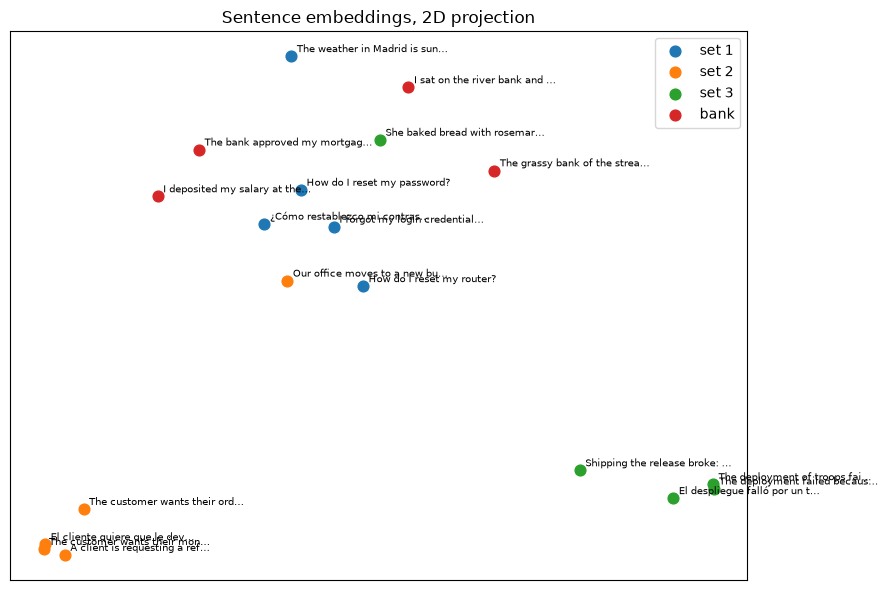

In [11]:
import matplotlib.pyplot as plt

texts, groups = [], []
for i, s in enumerate(DATA["embedding_sets"]):
    for t in [s["anchor"], *s["candidates"].values()]:
        texts.append(t); groups.append(f"set {i + 1}")
texts += DATA["bank"]; groups += ["bank"] * len(DATA["bank"])

X = embed(texts)
Xc = X - X.mean(axis=0)
_, _, vt = np.linalg.svd(Xc, full_matrices=False)
xy = Xc @ vt[:2].T

fig, ax = plt.subplots(figsize=(9, 6))
for g in dict.fromkeys(groups):
    idx = [i for i, gg in enumerate(groups) if gg == g]
    ax.scatter(xy[idx, 0], xy[idx, 1], label=g, s=60)
for (x, y), t in zip(xy, texts):
    ax.annotate(t[:28] + ("…" if len(t) > 28 else ""), (x, y), fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.set_title("Sentence embeddings, 2D projection"); ax.legend(); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 8. Findings

Every number below is computed from the cells above. These are the numbers the LinkedIn post uses.

In [12]:
f = {}
f["worked_example"] = {"text": ex_text, "pieces": ex_pieces, "ids": ex_ids, "n_tokens": len(ex_ids), "n_chars": len(ex_text)}
f["edge_cases"] = edge[["group", "text", "tokens", "pieces", "ids"]].to_dict("records")
f["totals"] = {lang: {c: int(totals.loc[lang, c]) for c in cols} for lang in ("en", "es")}
f["en_spread"] = {"min": int(en.min()), "max": int(en.max()), "pct": round(float((en.max() - en.min()) / en.min()), 3)}
f["es_over_en"] = {k: float(v) for k, v in zip(lang_cmp.tokenizer, lang_cmp["ES / EN"])}
f["chars_es_over_en"] = float(chars_ratio)
f["embedding_by_kind"] = by_kind.to_dict("index")
f["embedding_rows"] = sim.round(3).to_dict("records")
f["bank"] = bank_sim.to_dict()
Path("findings.json").write_text(json.dumps(f, indent=2, ensure_ascii=False))
print(json.dumps({k: f[k] for k in f if k not in ("embedding_rows", "edge_cases")}, indent=2, ensure_ascii=False))

{
  "worked_example": {
    "text": "Tokenization isn't free: 'unbelievably' costs more than 'good'.",
    "pieces": [
      "Token",
      "ization",
      " isn't",
      " free",
      ":",
      " '",
      "un",
      "bel",
      "ievably",
      "'",
      " costs",
      " more",
      " than",
      " '",
      "good",
      "'."
    ],
    "ids": [
      4421,
      2860,
      12471,
      2240,
      25,
      461,
      373,
      9880,
      153516,
      6,
      8959,
      945,
      1572,
      461,
      30744,
      6120
    ],
    "n_tokens": 16,
    "n_chars": 63
  },
  "totals": {
    "en": {
      "GPT-4 (cl100k)": 92,
      "GPT-4o (o200k)": 92,
      "Qwen2.5": 92,
      "XLM-R (multilingual)": 111
    },
    "es": {
      "GPT-4 (cl100k)": 151,
      "GPT-4o (o200k)": 128,
      "Qwen2.5": 151,
      "XLM-R (multilingual)": 138
    }
  },
  "en_spread": {
    "min": 92,
    "max": 111,
    "pct": 0.207
  },
  "es_over_en": {
    "GPT-4 (cl100k)": 1.64,
    "G